# AI Jobs Market 2025-2026: Análise Exploratória (EDA)

**Autor**: João Victor Neves Alves<br>
**Dataset**: AI Jobs Market 2025-2026 | Salaries (Kaggle: https://www.kaggle.com/datasets/alitaqishah/ai-jobs-market-2025-2026-salaries)<br>
**Objetivo**: Identificar tendências de salário, skills demandadas e oportunidades no mercado global de AI.

> **Sobre o dataset:** Compilado a partir de relatórios públicos de 
> mercado (Glassdoor, LinkedIn Workforce Insights, Bureau of Labor 
> Statistics, entre outros) referentes a 2025-2026. Os dados foram 
> modelados e normalizados pelo autor — salários representam 
> compensação anual total em USD equivalente (base + bônus).
> Métricas como `demand_growth_yoy_pct` são estimativas baseadas 
> nesses relatórios, não valores extraídos diretamente de vagas 
> individuais. Os insights refletem **tendências indicativas** 
> do mercado de IA, alinhadas com fontes reconhecidas do setor.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
import matplotlib.ticker as mticker

# Para o estilo dos gráficos:
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titleweight'] = 'bold'

# Para mostrar todos os dados nas colunas e não truncar
pd.set_option('display.max_columns', None) 

## 1. Carregamento dos dados e inspeção inicial

In [4]:
df = pd.read_csv('../data/ai_jobs_market_2025_2026.csv')

print(f'Shape: {df.shape}')
print(f'Colunas: {df.columns.tolist()}')
df.head()

Shape: (1500, 25)
Colunas: ['job_id', 'job_title', 'job_category', 'experience_level', 'years_of_experience', 'education_required', 'annual_salary_usd', 'salary_min_usd', 'salary_max_usd', 'city', 'country', 'remote_work', 'company_size', 'industry', 'required_skills', 'ai_salary_premium_pct', 'demand_score', 'demand_growth_yoy_pct', 'benefits_score_10', 'posting_year', 'posting_month', 'is_senior', 'is_remote_friendly', 'is_llm_role', 'salary_tier']


,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,country,remote_work,company_size,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,USA,On-site,Startup (1-50),Finance,APIs|Planning Systems|Python|Cloud|SQL|Leadership,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,UK,Hybrid,Enterprise (5000+),Finance,Python|Documentation|LLM APIs|Prompt Design|NL...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,USA,Fully Remote,Big Tech (FAANG+),Finance,Vector DBs|Python|Prompt Engineering|Fine-tuni...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,Singapore,Fully Remote,SME (51-500),Technology,Feature Stores|Spark|ETL|Airflow|dbt|SQL|Pytho...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,USA,Fully Remote,Enterprise (5000+),Automotive,Data Analysis|Stakeholder Mgmt|Agile|Cloud|Pro...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


In [5]:
df.tail()

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,country,remote_work,company_size,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
1495,AIJOB1496,Multimodal AI Engineer,AI Engineering,Lead (10+ yrs),8,Master's,262000.0,160000,300000,Toronto,Canada,Hybrid,SME (51-500),Retail,Python|Vision-Language Models|Fine-tuning|PyTo...,8.8,90,23.6,7.5,2026,1,1,1,0,Senior ($200-300k)
1496,AIJOB1497,NLP Engineer,AI Engineering,Senior (6-9 yrs),9,Bootcamp/Self-taught,163000.0,145000,290000,Berlin,Germany,On-site,Mid-size (501-5000),Manufacturing,Transformers|Text Processing|LLMs|Hugging Face...,6.7,91,66.5,7.8,2025,3,1,0,0,Upper-Mid ($150-200k)
1497,AIJOB1498,AI Compliance Manager,Governance,Mid (3-5 yrs),10,Master's,127000.0,100000,200000,Zurich,Switzerland,Hybrid,SME (51-500),Manufacturing,Documentation|Risk Management|Legal Knowledge|...,10.9,68,15.3,8.3,2026,3,0,1,0,Mid ($100-150k)
1498,AIJOB1499,NLP Engineer,AI Engineering,Lead (10+ yrs),4,Bachelor's,145000.0,145000,290000,Bangalore,India,Hybrid,Enterprise (5000+),Media,LLMs|Hugging Face|Python|Transformers|BERT|Tex...,8.5,91,78.8,7.4,2025,5,1,1,0,Mid ($100-150k)
1499,AIJOB1500,AI Security Engineer,Security,Lead (10+ yrs),5,Master's,229000.0,140000,260000,Berlin,Germany,Hybrid,Enterprise (5000+),Technology,Cybersecurity|ML Security|Red Teaming|Python|R...,12.2,80,9.0,8.6,2025,6,1,1,0,Senior ($200-300k)


O dataset contém **1.500 registros** e **25 colunas**, cobrindo informações 
sobre cargos, salários, skills, localização, modalidade de trabalho e 
métricas de demanda no mercado global de IA.

In [6]:
# Verificação dos tipos de valores e se há valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_id                 1500 non-null   object 
 1   job_title              1500 non-null   object 
 2   job_category           1500 non-null   object 
 3   experience_level       1500 non-null   object 
 4   years_of_experience    1500 non-null   int64  
 5   education_required     1500 non-null   object 
 6   annual_salary_usd      1500 non-null   float64
 7   salary_min_usd         1500 non-null   int64  
 8   salary_max_usd         1500 non-null   int64  
 9   city                   1500 non-null   object 
 10  country                1500 non-null   object 
 11  remote_work            1500 non-null   object 
 12  company_size           1500 non-null   object 
 13  industry               1500 non-null   object 
 14  required_skills        1500 non-null   object 
 15  ai_s

In [7]:
# Contagem de valores nulos por coluna
print("\n--- Valores nulos em cada coluna ---\n")
df.isna().sum()


--- Valores nulos em cada coluna ---



job_id                   0
job_title                0
job_category             0
experience_level         0
years_of_experience      0
education_required       0
annual_salary_usd        0
salary_min_usd           0
salary_max_usd           0
city                     0
country                  0
remote_work              0
company_size             0
industry                 0
required_skills          0
ai_salary_premium_pct    0
demand_score             0
demand_growth_yoy_pct    0
benefits_score_10        0
posting_year             0
posting_month            0
is_senior                0
is_remote_friendly       0
is_llm_role              0
salary_tier              0
dtype: int64

In [8]:
# Tabela completa com as informações pertinentes para análise:
pd.DataFrame({
    'dtype': df.dtypes,
    'nulos': df.isna().sum(),
    'únicos': df.nunique()
})

,dtype,nulos,únicos
job_id,object,0,1500
job_title,object,0,25
job_category,object,0,12
experience_level,object,0,4
years_of_experience,int64,0,15
education_required,object,0,5
annual_salary_usd,float64,0,248
salary_min_usd,int64,0,17
salary_max_usd,int64,0,16
city,object,0,20


In [9]:
# Verificação de Dados Duplicados
print("\n--- Verificando valores duplicados ---\n")
df.duplicated().sum()


--- Verificando valores duplicados ---



np.int64(0)

Com isso, percebe-se que o DataFrame está em um ótimo formato inicial, sem dados nulos e sem duplicatas.<br>
<br>
Apenas um ponto importante para a posterior análise dos dados, é interessante mudar o dtype dos seguintes campos:<br>
<br>
1. "experience_level"<br>
* São dados categoricos que variam pouco<br>
<br>
2. "remote_work"<br>
* São dados categoricos que variam pouco<br>
<br>
Para os demais casos que como "is_senior" que apresenta dados com características booleanas, e "posting_year" que seria o valor de uma data (somente ano), não serão modificados, pois não há necessidade que apresente vantagem e pode evitar possíveis warnings e acabar inserindo informações erradas do dataframe


In [10]:
df_update = df.copy()

exp_order = ['Entry (0-2 yrs)', 'Mid (3-5 yrs)', 'Senior (6-9 yrs)', 'Lead (10+ yrs)']
df_update['experience_level'] = pd.Categorical(df_update['experience_level'], categories=exp_order, ordered=True)

remote_order = ['On-site', 'Hybrid', 'Fully Remote']  # ajuste se necessário
df_update['remote_work'] = pd.Categorical(df_update['remote_work'], categories=remote_order, ordered=True)

In [11]:
df_update.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   job_id                 1500 non-null   object  
 1   job_title              1500 non-null   object  
 2   job_category           1500 non-null   object  
 3   experience_level       1500 non-null   category
 4   years_of_experience    1500 non-null   int64   
 5   education_required     1500 non-null   object  
 6   annual_salary_usd      1500 non-null   float64 
 7   salary_min_usd         1500 non-null   int64   
 8   salary_max_usd         1500 non-null   int64   
 9   city                   1500 non-null   object  
 10  country                1500 non-null   object  
 11  remote_work            1500 non-null   category
 12  company_size           1500 non-null   object  
 13  industry               1500 non-null   object  
 14  required_skills        1500 non-null   o

In [12]:
# Estatíscas descritivas para colunas numéricas
print("\n--- Estatísticas descritivas: colunas numéricas ---\n")
df_update.describe().round(2)


--- Estatísticas descritivas: colunas numéricas ---



,years_of_experience,annual_salary_usd,salary_min_usd,salary_max_usd,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role
count,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.0,1500.00,1500.00,1500.0,1500.00,1500.00
mean,6.22,194892.00,135448.67,257537.33,10.86,87.52,31.12,7.9,2025.58,3.97,0.5,0.75,0.22
std,2.68,66506.82,24448.95,39852.82,4.03,8.03,22.05,1.1,0.49,3.27,0.5,0.43,0.41
min,1.00,90000.00,90000.00,180000.00,3.00,68.00,5.00,6.0,2025.00,1.00,0.0,0.00,0.00
25%,4.00,144750.00,120000.00,218000.00,8.20,82.00,15.38,6.9,2025.00,2.00,0.0,1.00,0.00
50%,6.00,180000.00,140000.00,270000.00,10.50,89.00,23.40,7.9,2026.00,3.00,0.0,1.00,0.00
75%,8.00,236250.00,155000.00,290000.00,14.20,95.00,42.70,8.9,2026.00,5.00,1.0,1.00,0.00
max,15.00,384000.00,180000.00,320000.00,18.00,98.00,87.80,9.8,2026.00,12.00,1.0,1.00,1.00


In [13]:
# Estatíscas descritivas para colunas do tipo object e category
print("\n--- Estatísticas descritivas: colunas não-numéricas ---")
df_update.describe(include=['object', 'category'])



--- Estatísticas descritivas: colunas não-numéricas ---


,job_id,job_title,job_category,experience_level,education_required,city,country,remote_work,company_size,industry,required_skills,salary_tier
count,1500,1500,1500,1500,1500,1500,1500,1500,1500,1500,1500,1500
unique,1500,25,12,4,5,20,14,3,5,12,1500,5
top,AIJOB0001,LLM Engineer,AI Engineering,Entry (0-2 yrs),Master's,San Francisco,USA,Hybrid,Mid-size (501-5000),Automotive,APIs|Planning Systems|Python|Cloud|SQL|Leadership,Senior ($200-300k)
freq,1,75,736,385,316,92,515,686,312,138,1,467


### Observações das estatísticas descritivas

**Distribuição salarial:** A média de $194k supera a mediana de $180k, 
indicando assimetria positiva — salários muito altos em categorias como 
Architecture e Big Tech puxam a média para cima.

**Crescimento de demanda:** A média de 31% ao ano com desvio padrão de 22% 
sugere crescimento desigual entre categorias — vale investigar quais áreas 
estão crescendo mais (análise futura).

**Modalidade de trabalho:** Hybrid lidera com 45,7% das vagas, seguido de 
Fully Remote (29,7%). Trabalho presencial representa apenas 24,6% — 
o mercado de IA já opera majoritariamente de forma flexível.

**Categoria dominante:** AI Engineering concentra 49,1% de todas as vagas, 
refletindo a alta demanda por profissionais que desenvolvem e mantêm 
sistemas de IA diretamente.

In [14]:
# Atualizando novamente o dataframe atualizado
df = df_update.copy()
del df_update

## 2. Análise Exploratória de Dados (EDA)

### 2.1 Distribuição de Salários Anuais

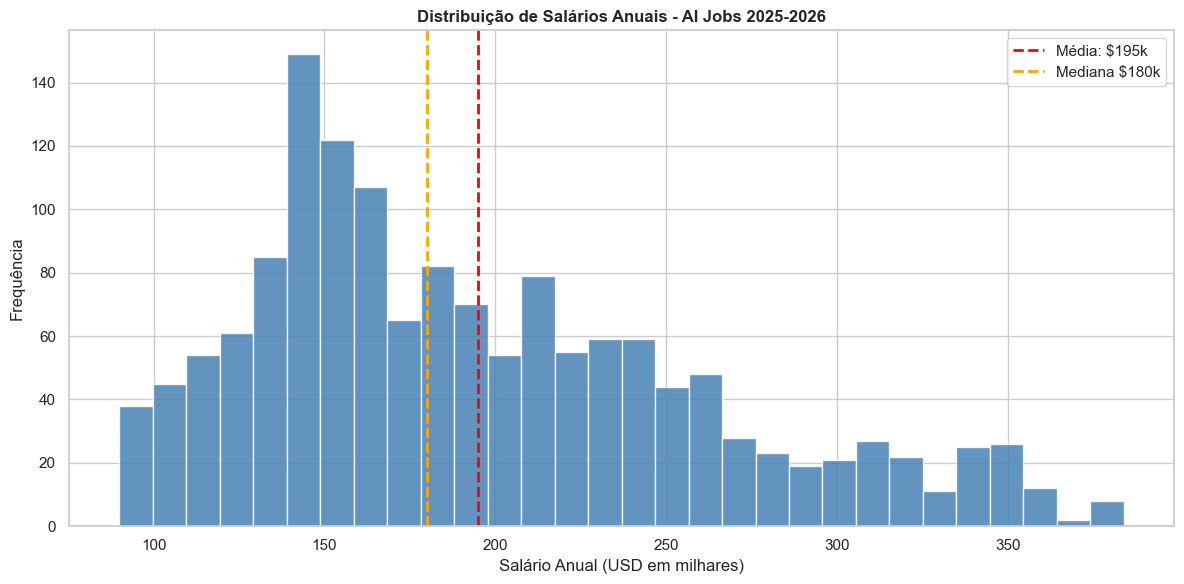

In [15]:
fig, ax = plt.subplots()

ax.hist(df['annual_salary_usd'] / 1000, bins=30, color='steelblue', edgecolor='white', alpha=0.85) #divisão por mil apenas para mostrar valores em milhares

ax.axvline(df['annual_salary_usd'].mean() / 1000, color='red', linestyle='--', lw=2, label=f'Média: ${df["annual_salary_usd"].mean()/1000:.0f}k') #Média

ax.axvline(df['annual_salary_usd'].median()/ 1000, color='orange', linestyle='--', lw=2, label=f'Mediana ${df["annual_salary_usd"].median()/1000:.0f}k') #Mediana

ax.set_title('Distribuição de Salários Anuais - AI Jobs 2025-2026')
ax.set_xlabel('Salário Anual (USD em milhares)')
ax.set_ylabel('Frequência')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/01_distribuicao_salarial.png', dpi=150, bbox_inches='tight')
plt.show()

**Observações:**
- A distribuição apresenta assimetria positiva (cauda à direita) — confirmada 
pela média ($195k) superior à mediana ($180k)
- O pico de frequência está concentrado entre $140k e $160k, onde se encontra 
a maior parte das vagas
- A cauda direita indica a presença de salários elevados acima de $300k, 
puxando a média para cima — típico de cargos sênior em Big Tech
- Não há um único salário dominante: o mercado de IA oferece uma ampla faixa 
salarial, refletindo a diversidade de cargos e regiões do dataset

### 2.2 Salário Médio por Categoria de Cargo

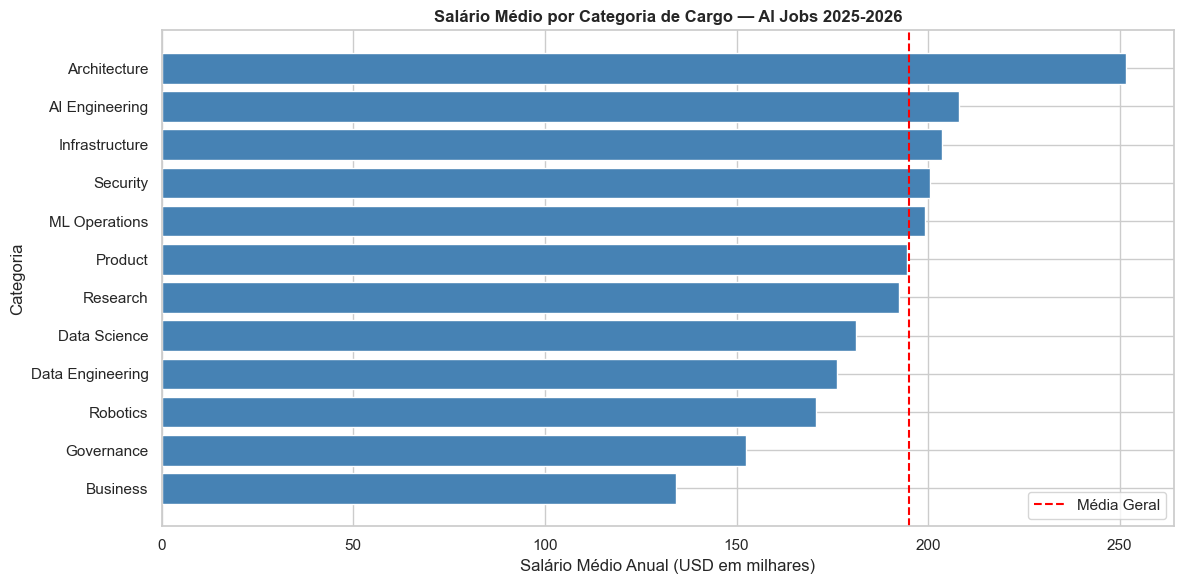

In [16]:
cat_sal = df.groupby('job_category')['annual_salary_usd'].mean().sort_values()

fig, ax = plt.subplots()

ax.barh(cat_sal.index, cat_sal.values / 1000, color='steelblue', edgecolor='white')

ax.axvline(df['annual_salary_usd'].mean() / 1000, color='red', linestyle='--', lw=1.5, label='Média Geral')

ax.set_title('Salário Médio por Categoria de Cargo — AI Jobs 2025-2026')
ax.set_xlabel('Salário Médio Anual (USD em milhares)')
ax.set_ylabel('Categoria')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/02_salario_por_categoria.png', dpi=150, bbox_inches='tight')
plt.show()

**Observações:**
- **Architecture** lidera com o maior salário médio (~$252k), seguida de 
**AI Engineering** (~$208k) e **Infrastructure** (~$204k)
- **7 das 12 categorias** ficam acima da média geral ($195k), indicando que 
o mercado de IA remunera bem a maioria das especialidades
- **Business** e **Governance** ficam significativamente abaixo da média — 
são categorias mais voltadas para gestão e compliance, com menor componente técnico
- Apesar de concentrar quase metade das vagas do dataset, **AI Engineering** 
ocupa a 2ª posição em salário — alta demanda e alta remuneração simultaneamente
- A diferença entre a categoria mais bem paga (Architecture, ~$252k) e a 
menos paga (Business, ~$134k) é de aproximadamente **$118k anuais** — 
evidenciando o impacto da especialização técnica na remuneração

> **Sobre a categoria Architecture no mercado de IA**
> 
> Diferente da arquitetura de software tradicional, profissionais dessa 
> categoria são responsáveis por **projetar a estrutura técnica de sistemas 
> de IA em larga escala**, definindo como modelos, pipelines de dados e 
> infraestrutura se conectam para suportar produtos de IA em produção.
> 
> **Cargos típicos:**
> - **AI Solutions Architect**: projeta soluções de IA para clientes ou produtos internos
> - **ML Platform Architect**: define a infraestrutura que suporta o ciclo de vida dos modelos
> - **Enterprise AI Architect**: integra IA em sistemas legados de grandes empresas
> - **Cloud AI Architect**: especializado em arquiteturas de IA em cloud (AWS, GCP, Azure)
> 
> O alto salário médio (~$252k) reflete a combinação de três fatores: 
> **visão sistêmica ampla** (dados, modelos, infra e negócio), **senioridade 
> elevada** (geralmente 8+ anos de experiência) e **escassez de profissionais** 
> com esse perfil no mercado.

### 2.3 Nível de Experiência vs. Salário

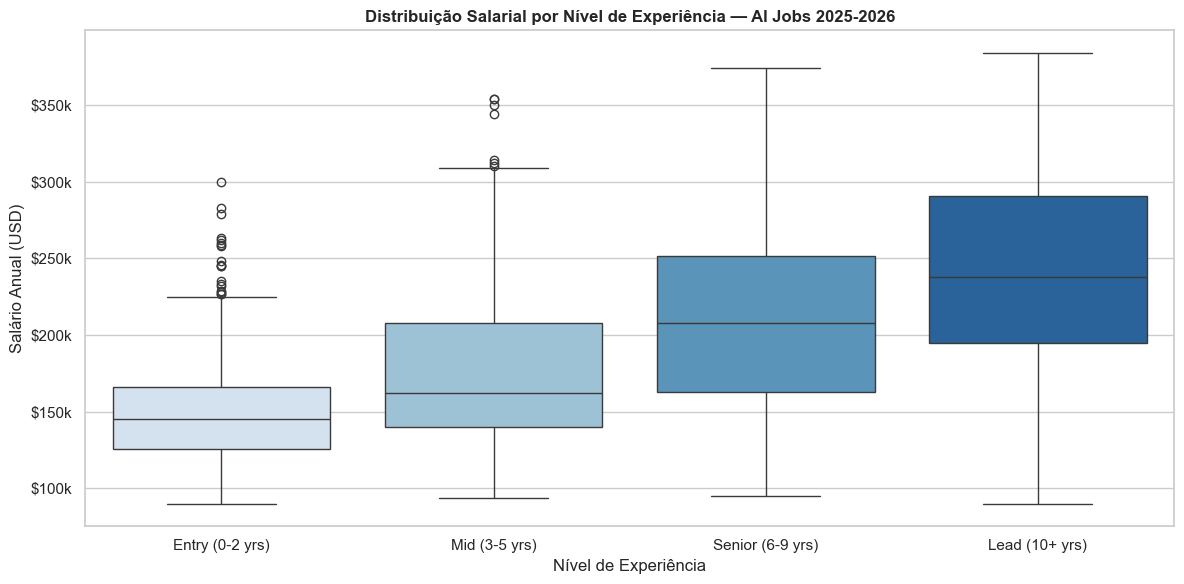

In [17]:
fig, ax = plt.subplots()

sns.boxplot(data=df, x='experience_level', y='annual_salary_usd', order=['Entry (0-2 yrs)', 'Mid (3-5 yrs)', 'Senior (6-9 yrs)', 'Lead (10+ yrs)'], palette='Blues', ax=ax)

ax.set_title('Distribuição Salarial por Nível de Experiência — AI Jobs 2025-2026')
ax.set_xlabel('Nível de Experiência')
ax.set_ylabel('Salário Anual (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('../outputs/03_experiencia_vs_salario.png', dpi=150, bbox_inches='tight')
plt.show()

**Observações:**
- A mediana salarial cresce de forma consistente com a experiência — 
de ~$150k (Entry) até ~$240k (Lead), uma progressão de aproximadamente 60%
- **Entry** é o nível mais comprimido (caixa menor) — salários concentrados 
entre $125k e $165k, pouca variação. O mercado paga de forma homogênea 
para quem está começando
- **Lead** apresenta a maior dispersão (caixa mais larga) — salários entre 
$195k e $290k, refletindo que profissionais sênior são avaliados de forma 
muito diferente dependendo da empresa e categoria
- Outliers em **Entry** e **Mid** indicam que mesmo profissionais com menos 
experiência podem atingir salários acima de $300k em categorias como 
Architecture e AI Engineering
- O salto mais expressivo acontece entre **Mid e Senior** — o momento de 
maior valorização na carreira em IA

### 2.4 Modalidade de Trabalho vs. Salário

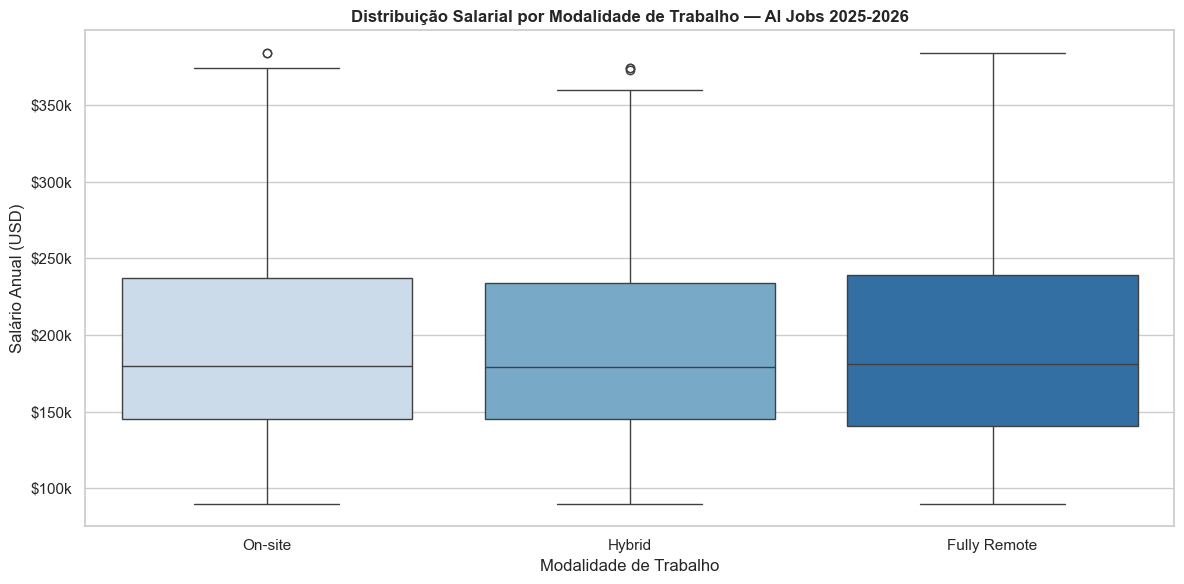

In [18]:
fig, ax = plt.subplots()

sns.boxplot(data=df, x='remote_work', y='annual_salary_usd', order=['On-site', 'Hybrid', 'Fully Remote'], palette='Blues', ax=ax)

ax.set_title('Distribuição Salarial por Modalidade de Trabalho — AI Jobs 2025-2026')
ax.set_xlabel('Modalidade de Trabalho')
ax.set_ylabel('Salário Anual (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('../outputs/04_remote_work.png', dpi=150, bbox_inches='tight')
plt.show()

**Observações:**
- As três modalidades apresentam medianas muito próximas (~$180k), indicando 
que a modalidade de trabalho **não é um fator determinante** no salário 
dentro do mercado de IA
- **Fully Remote** tem a maior dispersão (caixa mais larga) — salários entre 
$140k e $240k, sugerindo que vagas remotas abrangem tanto posições mais 
simples quanto as mais bem pagas do dataset
- A presença de outliers em **On-site** e **Hybrid** acima de $370k reforça 
que os maiores salários estão concentrados em empresas que exigem presença 
física ou modelo híbrido — provavelmente Big Tech em grandes centros
- Conclusão: **escolher remoto para ganhar mais não é uma estratégia eficaz 
no mercado de IA** — o salário é mais determinado pela categoria e nível de 
experiência do que pela modalidade de trabalho

### 2.5 Top Países por Salário Médio

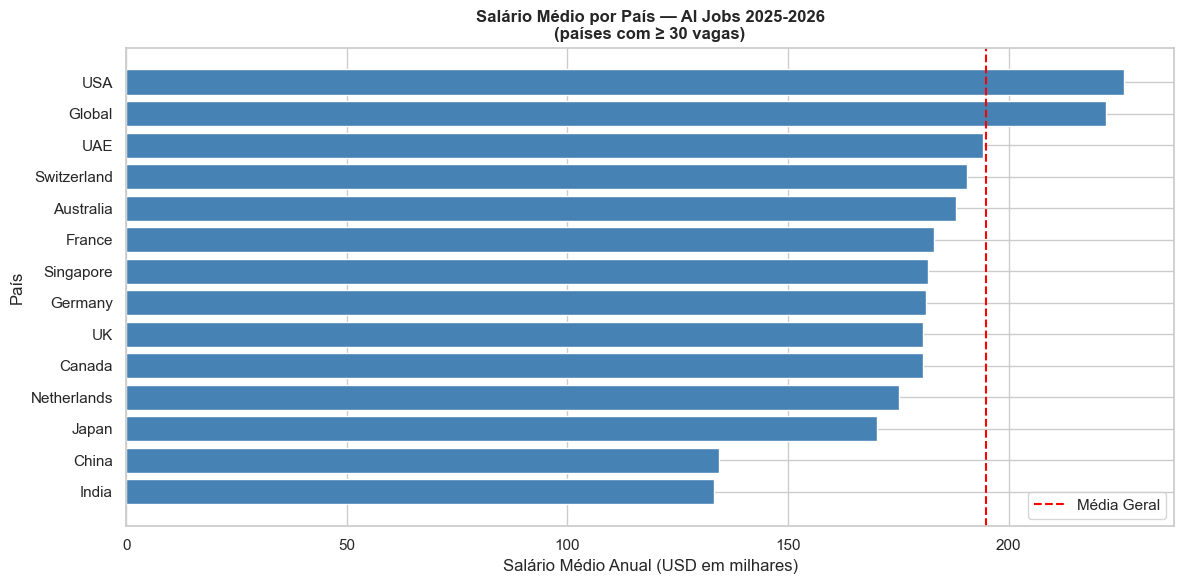

In [19]:
country_sal = df.groupby('country')['annual_salary_usd'].agg(mean='mean', count='count').query('count >= 30').sort_values('mean')

fig, ax = plt.subplots()

ax.barh(country_sal.index, country_sal['mean']/1000, color='steelblue', edgecolor='white')

ax.axvline(df['annual_salary_usd'].mean() / 1000, color='red', linestyle='--', lw=1.5, label='Média Geral')

ax.set_title('Salário Médio por País — AI Jobs 2025-2026\n(países com ≥ 30 vagas)')
ax.set_xlabel('Salário Médio Anual (USD em milhares)')
ax.set_ylabel('País')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/05_salario_por_pais.png', dpi=150, bbox_inches='tight')
plt.show()

Valor "Global" provavelmente representa vagas onde o país foi preenchido com esse nome no dataset. Isso pode ser típico de vagas que são 100% remotas, sem vículo com um país específico. Entretanto, vale investigar esse valor.

In [20]:
# Verificar o que é "Global"
print(df[df['country'] == 'Global'][['job_title', 'remote_work', 'country']].head(10))
print(f"\nTotal de vagas Global: {len(df[df['country'] == 'Global'])}")

                    job_title   remote_work country
7          Senior ML Engineer  Fully Remote  Global
31      AI Infrastructure Eng        Hybrid  Global
43         Senior ML Engineer        Hybrid  Global
48   Computer Vision Engineer       On-site  Global
76      AI Infrastructure Eng        Hybrid  Global
86             MLOps Engineer        Hybrid  Global
98     Robotics Engineer (AI)        Hybrid  Global
100        Senior ML Engineer       On-site  Global
108  Computer Vision Engineer  Fully Remote  Global
118            MLOps Engineer       On-site  Global

Total de vagas Global: 82


O dataset contém 82 vagas classificadas com país "Global". 
Uma análise inicial mostra que essas vagas incluem as três modalidades 
de trabalho (Remote, Hybrid e On-site), o que sugere que "Global" 
não representa necessariamente vagas remotas sem localização definida, 
mas possivelmente vagas onde o país de origem não foi especificado 
no cadastro.

**Hipóteses:**
- Vagas de empresas multinacionais abertas para múltiplas localidades
- Vagas onde a localização não foi informada pelo recrutador
- Vagas 100% remotas sem vínculo geográfico definido

Por essa razão, "Global" foi mantido na análise como uma categoria 
independente, sem ser tratado como um país específico. Seu salário 
médio (~$205k) está acima da média geral ($195k), o que pode indicar 
que empresas que operam globalmente tendem a oferecer remunerações 
mais competitivas.

**Observações:**
- **USA** lidera com o maior salário médio (~$220k), seguido de **Global** 
(~$205k) e **UAE** (~$195k)
- Apenas esses **3 países** ficam acima da média geral ($195k): USA, Global e UAE — 
o mercado de IA ainda é fortemente concentrado nos Estados Unidos
- **Europa bem representada** — Switzerland, Australia, France, Singapore, 
Germany, UK e Canada aparecem em faixa próxima entre $180k e $190k, 
indicando um mercado europeu relativamente uniforme em remuneração
- **China e India** ficam significativamente abaixo da média geral (~$135k) — 
diferença de aproximadamente $85k em relação aos EUA, refletindo 
diferenças no custo de vida e maturidade do mercado local de IA
- **14 países** passaram pelo filtro de 30 vagas, demonstrando que o 
mercado de IA já é genuinamente global, com representatividade 
em múltiplos continentes

### 2.6 Skills Mais Demandadas

O que é preciso aprender para entrar no mercado de IA?

Desafio: a coluna required_skills armazena múltiplas skills por linha separadas por "|". Será preciso ajustar isso para a análise.

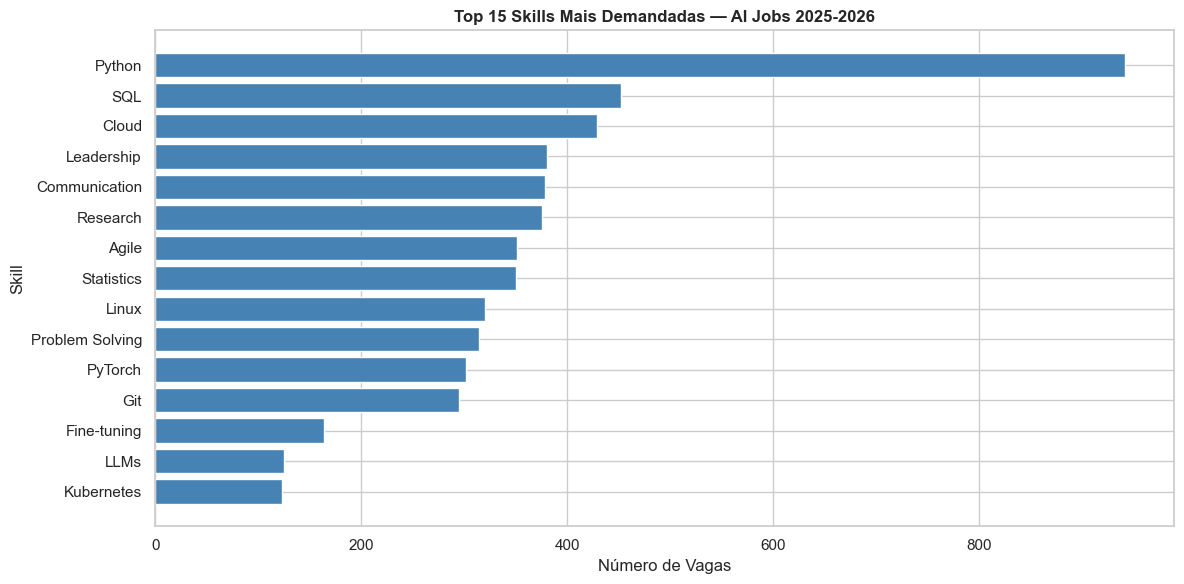

In [21]:
# Explodir a coluna de skills
all_skills = []
for row in df['required_skills']:
    all_skills.extend([s.strip() for s in row.split('|')])

# Contar frequência de cada skill
skills_df = pd.DataFrame(
    Counter(all_skills).most_common(15), columns=['skill', 'count']
)
skills_df['pct'] = (skills_df['count'] / len(df) * 100).round(1)

# Gráfico
fig, ax = plt.subplots()

ax.barh(skills_df['skill'][::-1], skills_df['count'][::-1], color='steelblue', edgecolor='white')

ax.set_title('Top 15 Skills Mais Demandadas — AI Jobs 2025-2026')
ax.set_xlabel('Número de Vagas')
ax.set_ylabel('Skill')

plt.tight_layout()
plt.savefig('../outputs/06_top_skills.png', dpi=150, bbox_inches='tight')
plt.show()

**Observações:**
- **Python domina de forma absoluta** — presente em ~900 vagas, quase o dobro 
da segunda colocada (SQL ~440). É a skill mais universal do mercado de IA, 
independente da categoria ou nível de experiência
- **SQL e Cloud** completam o top 3 técnico — confirmando que manipulação 
de dados e infraestrutura em nuvem são competências base para qualquer 
profissional de IA
- **Soft skills no top 5** — Leadership e Communication aparecem à frente de 
skills técnicas como Statistics e Linux, reforçando que o mercado de IA 
não busca apenas especialistas técnicos, mas profissionais capazes de 
comunicar e liderar
- **Skills de LLM ainda emergentes** — Fine-tuning, LLMs e Kubernetes aparecem 
no bottom do top 15 com menos de 200 vagas cada, indicando que são 
competências ainda em ascensão mas que tendem a crescer com a expansão 
do mercado de modelos de linguagem
- **PyTorch e Git** na faixa de 300 vagas — essenciais para quem atua 
diretamente com desenvolvimento e treinamento de modelos

### 2.7 Crescimento de Demanda YoY por Categoria

> **Nota sobre `demand_growth_yoy_pct`:** Esta métrica é uma estimativa 
> por vaga calculada pelo autor do dataset a partir de relatórios de mercado 
> (Glassdoor, LinkedIn Workforce Insights, BLS, entre outros) — não um valor 
> extraído diretamente de postagens individuais. O dataset cobre vagas de 
> 2025 a 2026, com parte dos dados projetados a partir dessas fontes.
> Os valores de crescimento YoY devem ser interpretados como **tendências 
> indicativas de mercado**, não como métricas verificadas por vaga.

In [22]:
print(df['posting_year'].value_counts())
print()
print(df['posting_month'].value_counts().sort_index())

posting_year
2026    876
2025    624
Name: count, dtype: int64

posting_month
1     312
2     361
3     351
4      41
5      64
6      57
7      57
8      39
9      47
10     44
11     59
12     68
Name: count, dtype: int64


In [23]:
print(df[['job_category', 'posting_year', 'demand_growth_yoy_pct']].head(10))
print()
print(f"Período coberto: {df['posting_year'].min()} mês {df['posting_month'].min()} até {df['posting_year'].max()} mês {df['posting_month'].max()}")

       job_category  posting_year  demand_growth_yoy_pct
0    AI Engineering          2026                   16.9
1    AI Engineering          2026                   11.6
2    AI Engineering          2026                   42.7
3  Data Engineering          2026                    6.7
4           Product          2026                   17.3
5    AI Engineering          2026                   67.7
6          Security          2026                   12.7
7    AI Engineering          2025                   33.1
8    AI Engineering          2025                   79.4
9    AI Engineering          2025                   15.5

Período coberto: 2025 mês 1 até 2026 mês 12


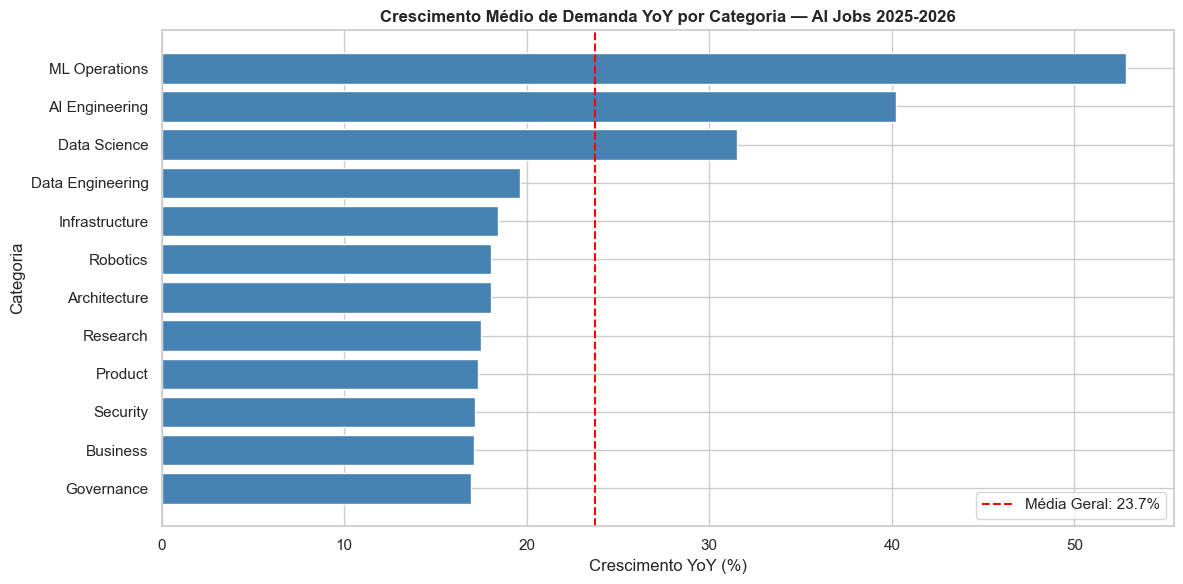

In [ ]:
yoy = df.groupby('job_category')['demand_growth_yoy_pct'].mean().sort_values()

fig, ax = plt.subplots()

ax.barh(yoy.index, yoy.values, color='steelblue', edgecolor='white')

ax.axvline(yoy.mean(), color='red', linestyle='--', lw=1.5, label=f'Média Geral: {yoy.mean():.1f}%')

ax.set_title('Crescimento Médio de Demanda YoY por Categoria — AI Jobs 2025-2026')
ax.set_xlabel('Crescimento YoY (%)')
ax.set_ylabel('Categoria')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/07_crescimento_yoy.png', dpi=150, bbox_inches='tight')
plt.show()

**Observações** *(valores indicativos — ver nota acima)*:
- **ML Operations lidera com ~53% de crescimento YoY** — a categoria com 
maior expansão do mercado, refletindo a crescente necessidade de 
profissionais que operacionalizam modelos de IA em produção
- **AI Engineering (~40%)** aparece em segundo — alta demanda e alto salário 
simultaneamente, confirmando ser o sweet spot do mercado de IA no momento
- Apenas **3 categorias** ficam acima da média geral (23.7%): ML Operations, 
AI Engineering e Data Science — crescimento concentrado nas áreas mais 
técnicas e diretamente ligadas a modelos
- **Architecture** aparece abaixo da média (~18%) — apesar de ser a categoria 
mais bem paga (Gráfico 2), seu crescimento é moderado, sugerindo que 
é um nicho com alta remuneração mas vagas mais escassas e seletivas
- **Governance (~16%)** tem o menor crescimento — ainda é uma área emergente 
em termos de regulação de IA, mas tende a ganhar relevância com o avanço 
de legislações como o AI Act europeu
- **Combinando com o Gráfico 2:** AI Engineering é a categoria com melhor 
equilíbrio entre salário (~$208k) e crescimento (~40%) — o melhor 
custo-benefício para quem está escolhendo uma especialização em IA

### 2.8 Tamanho de Empresa vs. Salário e Benefícios

Vale mais a pena uma Startup ou uma Big Tech?

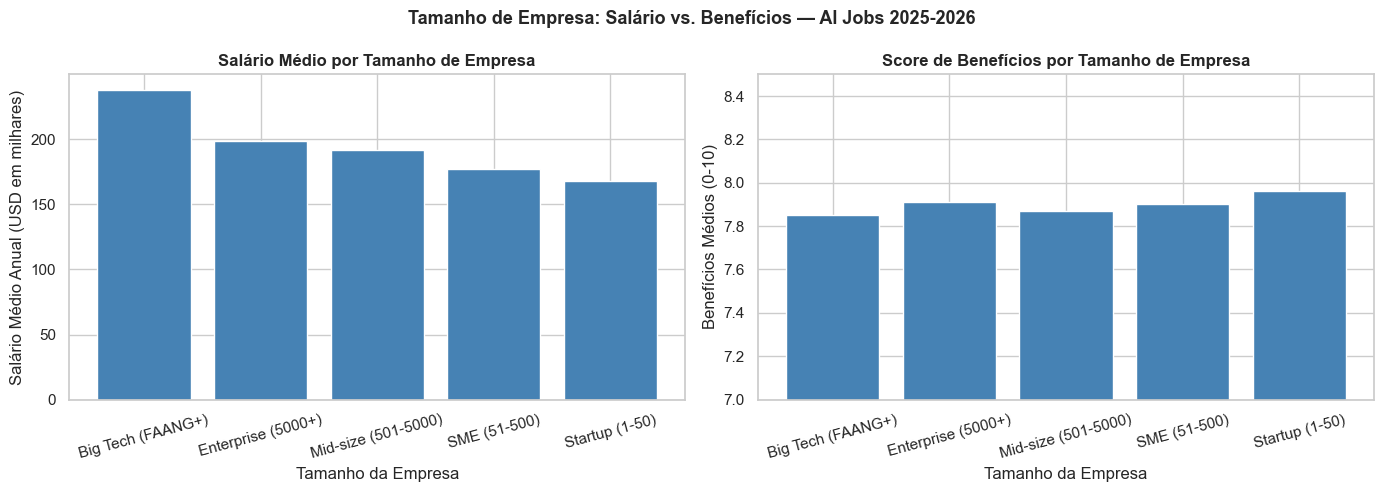

In [25]:
company_data = df.groupby('company_size').agg(mean_salary=('annual_salary_usd', 'mean'), mean_benefits=('benefits_score_10', 'mean')).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1 — Salário médio
axes[0].bar(company_data.index, company_data['mean_salary'] / 1000, color='steelblue', edgecolor='white')
axes[0].set_title('Salário Médio por Tamanho de Empresa')
axes[0].set_xlabel('Tamanho da Empresa')
axes[0].set_ylabel('Salário Médio Anual (USD em milhares)')
axes[0].tick_params(axis='x', rotation=15)

# Gráfico 2 — Score de benefícios
axes[1].bar(company_data.index, company_data['mean_benefits'], color='steelblue', edgecolor='white')
axes[1].set_title('Score de Benefícios por Tamanho de Empresa')
axes[1].set_xlabel('Tamanho da Empresa')
axes[1].set_ylabel('Benefícios Médios (0-10)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].set_ylim(7, 8.5) # ajuste para destacar melhor a variação

plt.suptitle('Tamanho de Empresa: Salário vs. Benefícios — AI Jobs 2025-2026', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/08_llm_roles.png', dpi=150, bbox_inches='tight')
plt.show()

**Observações:**
- **Big Tech (FAANG+) lidera em salário com ~$230k** — aproximadamente 
$65k a mais que Startups (~$165k), uma diferença de quase 40%
- A progressão salarial é clara e consistente: quanto maior a empresa, 
maior o salário médio — sem exceções neste dataset
- **Benefícios contam uma história diferente** — Startups lideram 
levemente em score de benefícios (~7.97), enquanto Big Tech tem o 
menor score (~7.84). A diferença é pequena mas contraria a intuição 
de que grandes empresas oferecem os melhores pacotes. Entretanto, vale 
considerar que manter um score próximo de 7.8 para uma base de 
colaboradores muito maior é um indicativo de robustez nos pacotes 
oferecidos por Big Techs.
- A variação nos benefícios é muito pequena entre todos os portes 
(7.84 a 7.97) — na prática, benefícios são relativamente uniformes 
no mercado de IA independente do tamanho da empresa
- **Conclusão:** para quem prioriza salário, Big Tech é a escolha clara. 
Para quem busca equilíbrio entre remuneração e benefícios, empresas 
Mid-size e SME oferecem uma combinação competitiva sem a pressão 
típica de ambientes FAANG

### 2.9 LLM Roles: Nicho Premium?

Especializar-se em LLMs vale financeiramente? 

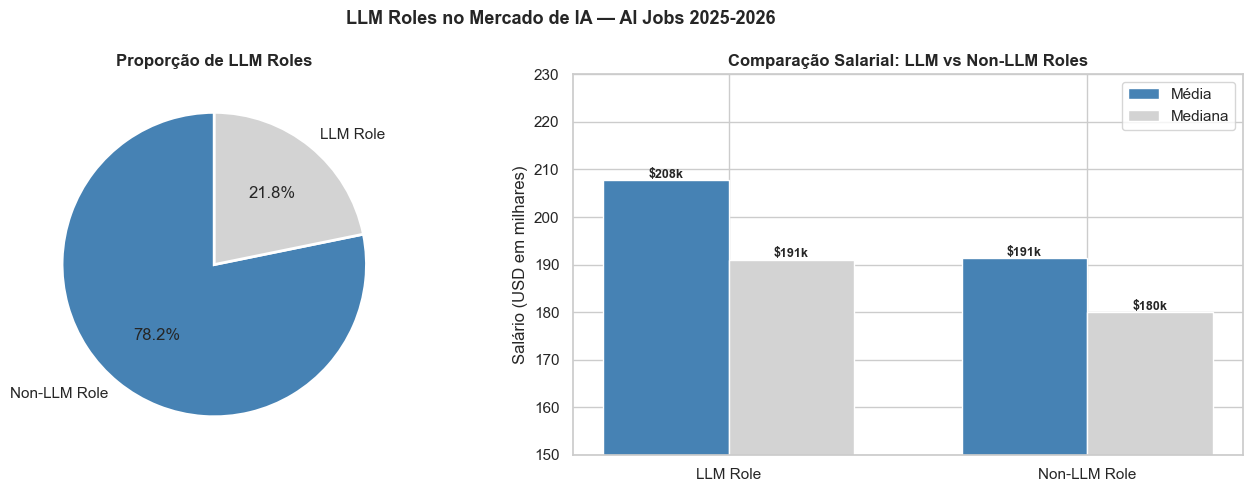

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1 — Proporção LLM vs Non-LLM
llm_counts = df['is_llm_role'].map({1: 'LLM Role', 0: 'Non-LLM Role'}).value_counts()

axes[0].pie(llm_counts.values, labels=llm_counts.index, autopct='%1.1f%%', startangle=90, colors=['steelblue', '#d3d3d3'], wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Proporção de LLM Roles')

# Gráfico 2 — Comparação salarial
llm_sal = df.groupby(df['is_llm_role'].map({1: 'LLM Role', 0: 'Non-LLM Role'}))['annual_salary_usd'].agg(Média='mean', Mediana='median') / 1000

x = np.arange(2)
width = 0.35

bars1 = axes[1].bar(x - width/2, llm_sal['Média'], width, label='Média', color='steelblue', edgecolor='white')
bars2 = axes[1].bar(x + width/2, llm_sal['Mediana'], width, label='Mediana', color='#d3d3d3', edgecolor='white')

for bar in list(bars1) + list(bars2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'${bar.get_height():.0f}k', ha='center', fontsize=9, fontweight='bold')

axes[1].set_xticks(x)
axes[1].set_xticklabels(llm_sal.index)
axes[1].set_title('Comparação Salarial: LLM vs Non-LLM Roles')
axes[1].set_ylabel('Salário (USD em milhares)')
axes[1].set_ylim(150, 230)
axes[1].legend()

plt.suptitle('LLM Roles no Mercado de IA — AI Jobs 2025-2026', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/09_empresa_vs_salario.png', dpi=150, bbox_inches='tight')
plt.show()

**Observações:**
- **LLM Roles representam apenas 21.8% das vagas** — ainda é um nicho 
no mercado de IA, com Non-LLM Roles dominando 78.2% das oportunidades
- **LLM Roles pagam em média $208k vs $191k dos Non-LLM** — um prêmio 
salarial de aproximadamente 8.9% para quem se especializa em 
modelos de linguagem
- **A mediana conta uma história mais expressiva** — $191k (LLM) vs 
$180k (Non-LLM), diferença de ~6% — confirmando que o prêmio 
salarial é real e não apenas puxado por outliers
- A diferença entre média e mediana é maior nos LLM Roles ($208k vs 
$191k) do que nos Non-LLM ($191k vs $180k), indicando que existem 
salários muito altos em LLM que puxam a média para cima
- **Conclusão:** especializar-se em LLMs oferece um prêmio salarial 
real, mas ainda é um nicho — quem domina essa área compete por 
menos vagas e com salários superiores. Com a expansão contínua 
de modelos de linguagem, a tendência é que essa categoria 
cresça em volume nos próximos anos

## 3. Conclusões e Principais Insights

A análise exploratória do dataset **AI Jobs Market 2025-2026** revelou 
tendências relevantes sobre o mercado global de empregos em IA. 
Abaixo estão os principais insights identificados:

### Salário e Remuneração
- O salário médio no mercado de IA é de **$195k/ano**, com distribuição 
assimétrica — a maioria das vagas se concentra entre $140k e $160k, 
mas salários acima de $300k puxam a média para cima
- **Architecture** é a categoria mais bem remunerada (~$230k), seguida 
de AI Engineering (~$208k) — ambas exigem alto grau de especialização 
técnica e experiência
- A progressão de carreira tem impacto direto no salário: profissionais 
**Lead (10+ anos)** ganham aproximadamente **60% a mais** que Entry 
(0-2 anos)

### Mercado e Demanda
- **ML Operations (+53% YoY)** e **AI Engineering (+40% YoY)** são as 
categorias com maior crescimento de demanda — combinando com seus 
altos salários, representam o maior potencial para quem está 
escolhendo uma especialização
- O mercado de IA é genuinamente global, com **14 países** representados 
no dataset, mas os EUA seguem liderando em volume de vagas e 
remuneração (~$220k)

### Skills e Perfil Profissional
- **Python** é a skill mais demandada. Está presente em ~60% das vagas, 
muito à frente de SQL e Cloud que completam o top 3
- Soft skills como **Leadership** e **Communication** aparecem no top 5, 
à frente de skills técnicas como Statistics e Linux. Isso mostra que o mercado 
de IA valoriza profissionais completos, não apenas especialistas técnicos

### Empresa e Modalidade
- **Big Tech (FAANG+)** paga ~40% a mais que Startups ($230k vs $165k), 
mas benefícios são surpreendentemente uniformes entre todos os portes 
de empresa (7.84 a 7.97, em uma escala de 0 a 10)
- A modalidade de trabalho **não é um fator determinante no salário**. 
As medianas de Remote, Hybrid e On-site são praticamente iguais (~$180k)

### LLM Roles
- LLM Roles representam apenas **21.8% das vagas** mas pagam um prêmio 
de **~8.9%** em relação a Non-LLM Roles. Especialização em modelos 
de linguagem ainda é um nicho premium com tendência de crescimento

---

### Próximos Passos
- **Fase 2:** Análise com SQL (DuckDB) — aprofundamento dos insights 
com queries analíticas
- **Fase 3:** Dashboard interativo no Power BI
- **Fase 4:** Apresentação dos insights para stakeholders
- **Fase 5:** Publicação no GitHub e LinkedIn

In [26]:
skills_df[['skill', 'count', 'pct']].to_csv( '../outputs/skills_top15.csv', index=False)

print('✅ skills_top15.csv exportado!')

✅ skills_top15.csv exportado!
